# Step 1 Data Processing
Apply appropriate techniques to preprocess data (e.g., normalization, standardization)

In [1]:
## Data Processing libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

passenger = pd.read_csv("titanic_augmented.csv")

passenger.shape

(891, 26)

In [2]:
passenger.tail(6)
passenger.iloc[:, 0:13]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,name_length
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,23
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,51
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,22
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,44
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,21
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,28
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,40
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,21


In [3]:
passenger.iloc[:, 13:25]

,title,title_group,family_size,is_alone,ticket_group_size,fare_per_person,age_fare_ratio,cabin_deck,cabin_room_number,booking_reference,service_id,cabin_score
0,Mr,Mr,2,0,1,7.250,3.034483,Unknown,NaN,92490,221958,6.134152
1,Mrs,Mrs,2,0,1,71.283,0.533084,C,85.0,15655423,771155,4.182430
2,Miss,Miss,1,1,1,7.925,3.280757,Unknown,NaN,90218500,231932,9.327285
3,Mrs,Mrs,2,0,2,26.550,0.659134,C,123.0,2493079,465838,8.660639
4,Mr,Mr,1,1,1,8.050,4.347826,Unknown,NaN,59517148,359178,0.452187
...,...,...,...,...,...,...,...,...,...,...,...,...
886,Rev,Other,1,1,1,13.000,2.076923,Unknown,NaN,83757278,538661,4.308875
887,Miss,Miss,1,1,1,30.000,0.633333,B,42.0,91664020,498929,2.487143
888,Miss,Miss,4,0,2,11.725,0.000000,Unknown,NaN,55618889,680466,6.171450
889,Mr,Mr,1,1,1,30.000,0.866667,C,148.0,94737372,673695,7.067772


In [4]:
passenger.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,is_alone,ticket_group_size,fare_per_person,age_fare_ratio,cabin_deck,cabin_room_number,booking_reference,service_id,cabin_score,name_word_count
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,...,891.000000,891.000000,891.000000,891.000000,891,200.00000,8.910000e+02,891.000000,891.000000,891.000000
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,...,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,...,NaN,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,...,NaN,NaN,NaN,NaN,687,NaN,NaN,NaN,NaN,NaN
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,...,0.602694,1.787879,17.789001,1.572536,NaN,50.49000,5.108118e+07,536369.988777,4.956762,4.067340
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,...,0.489615,1.361142,21.218127,1.661773,NaN,35.39497,2.838174e+07,261551.630299,2.915177,1.168866
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,...,0.000000,1.000000,0.000000,0.000000,NaN,2.00000,9.249000e+04,102869.000000,0.046320,3.000000
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,...,0.000000,1.000000,7.762500,0.116026,NaN,22.00000,2.831962e+07,299638.000000,2.325861,3.000000
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,...,1.000000,1.000000,8.850000,1.175795,NaN,43.00000,5.128853e+07,535564.000000,4.954913,4.000000
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,...,1.000000,2.000000,24.288000,2.543045,NaN,77.25000,7.493131e+07,757663.000000,7.479345,4.000000


# Step 2 Data Splitting and Resampling
Split the dataset into training and test sets (25% test) and use appropriate resampling techniques (e.g., k-fold cross-validation) to ensure robust model evaluation.

In [5]:
passenger.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PassengerId        891 non-null    int64  
 1   Survived           891 non-null    int64  
 2   Pclass             891 non-null    int64  
 3   Name               891 non-null    object 
 4   Sex                891 non-null    object 
 5   Age                714 non-null    float64
 6   SibSp              891 non-null    int64  
 7   Parch              891 non-null    int64  
 8   Ticket             891 non-null    object 
 9   Fare               891 non-null    float64
 10  Cabin              204 non-null    object 
 11  Embarked           889 non-null    object 
 12  name_length        891 non-null    int64  
 13  title              891 non-null    object 
 14  title_group        891 non-null    object 
 15  family_size        891 non-null    int64  
 16  is_alone           891 non

In [6]:
# Drop Irrelevant, Weak, Redundant Features
drop_cols = [
    "PassengerId",    # identifier
    "Name",           # title already extracted
    "Ticket",         # too high-cardinality
    "Cabin",           # raw cabin string; usually replaced by deck
    "name_length",                  # Too many missing data and it is redundant to the decomposed ones
    "name_word_count",      # Weak predictor
    "title",           # Keep the title_group instead
    "cabin_room_number",
    "booking_reference",
    "service_id"
]

cols_dropping = [col for col in drop_cols if col in passenger.columns]
passenger_clean = passenger.drop(columns=cols_dropping)


# Separate Predictors and Response 
target = "Survived"
X = passenger_clean.drop(columns=[target])
y = passenger_clean[target]

# separate numeric and categories for future pipelining
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

if 'Pclass' in num_features:
    num_features.remove('Pclass')
    cat_features.append('Pclass')

# Pipelining
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_features),
        ('cat', categorical_pipeline, cat_features)
    ]
)

preprocessing_only = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Splitting train/test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y   # preserves class ratio
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Survival rate in full dataset:", y.mean())
print("Survival rate in training set:", y_train.mean())
print("Survival rate in test set:", y_test.mean())

# CV re-sampling
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#StratifiedKFold(n_splits=10)


# example placeholder for a model
logreg_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),   # from earlier step
    ('model', LogisticRegression(max_iter=1000))
])

# useful in the future
# scores = cross_val_score(
#     logreg_pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring='accuracy'
# )

# print("CV Accuracy:", scores)
# print("Mean Accuracy:", scores.mean())

##Check for missing value]
# X_check = preprocessing_only.fit_transform(X_train)
# X_check.shape
# np.isnan(X_check).sum()

Training set size: (668, 15)
Test set size: (223, 15)
Survival rate in full dataset: 0.3838383838383838
Survival rate in training set: 0.38323353293413176
Survival rate in test set: 0.38565022421524664


## Random Forest

### RF baseline (5-fold Stratified CV on training set)

we trained a baseline RF classifier using a preprocessing + model pipline, and evaluated its expected generalization performance using 5-fold Stratified cross_validation on the training set only (seed =42).

cross_val_score fits the full pipeline from scratch in each fold, meaning that imputation/encoding (and scaling, if included) are learned only from the fold's training portion, which helps prevent data leakage.

The 5 fold accuracies were [0.79850746 0.84328358 0.84328358 0.82706767 0.79699248], giving a mean CV accuracy of 82% with sd 2.05%.

This mean score serves as our baseline benchmark for later hyperparameter tuning and feature reduction (small yet performant), while the relatively small standard deviation indicates the model performance is fairly stable across folds.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

#random forest baseline pipline
rf_pipline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1))
])

rf_scores = cross_val_score(
    rf_pipline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("RF CV scores:", rf_scores)
print("RF Mean CV accuracy:", rf_scores.mean())
print("RF Std CV accuracy:", rf_scores.std())

RF CV scores: [0.79850746 0.84328358 0.84328358 0.82706767 0.79699248]
RF Mean CV accuracy: 0.8218269554483222
RF Std CV accuracy: 0.020536740674665727


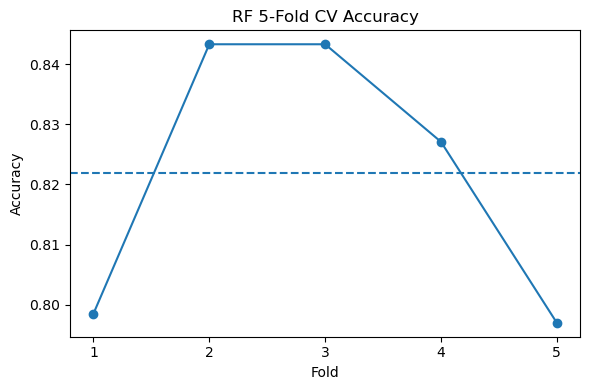

Mean CV accuracy: 0.8218269554483222
Std CV accuracy: 0.020536740674665727


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# example: rf_scores = cross_val_score(...)
plt.figure(figsize=(6,4))
plt.plot(range(1, len(rf_scores)+1), rf_scores, marker="o")
plt.axhline(rf_scores.mean(), linestyle="--")

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("RF 5-Fold CV Accuracy")
plt.xticks(range(1, len(rf_scores)+1))
plt.tight_layout()
plt.show()

print("Mean CV accuracy:", rf_scores.mean())
print("Std CV accuracy:", rf_scores.std())


### Random Forest Hyperparameter Tuning

We tuned the RF classifier using RandomizedSearchCV with 5-fold stratified CV on the training set only. The best configuration achieved a mean CV accuracy of 83.53%, improving over the baseline RF mean CV accuracy (82.18%).

The selected hyperparameters suggest a variance-reduction + regularization trade-off: using a large number of trees (n_estimators=1200) stabilizes the ensemble, while constraints on node splitting (min_samples_split=10, min_samples_leaf=2) reduce overfitting from overly specific splits. 

In addition, max_features=0.5 increases tree diversity by limiting the candidate predictors considered at each split, reducing correlation between trees and improving the effectiveness of majority voting.

The best model did not required class reweighting (class_weight=None), indicating that accuracy performance was strongest without additional imbalance correction.

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

#preprocessing + RF
rf_pipeline = Pipeline(steps = [
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# check p before one-hot encoding
p_raw = X_train.shape[1]
print("p (raw features):", p_raw)

# p after after one-hot 
X_train_transformed = preprocessor.fit_transform(X_train)
p_after = X_train_transformed.shape[1]
print("p (after preprocessing):", p_after)

#Hyperparameter search space (moderate size, good chance to improve baseline)
param_dist = {
    "model__n_estimators": [300, 500, 800, 1200], # more trees => more stable, slower
    "model__max_depth": [None, 5, 10, 20, 30],    # tree complexity control
    "model__min_samples_leaf": [1, 2, 5, 10],     # larger leaf => less overfitting
    "model__min_samples_split": [2, 5, 10],       # prevents tiny splits
    "model__max_features": ["sqrt", 0.3, 0.5],    # RF key: randomness per split
    "model__class_weight": [None, "balanced"]     # optional for imbalance
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=30,             
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)
print("Best CV accuracy:", rf_search.best_score_)
print("Best params:", rf_search.best_params_)

p (raw features): 15
p (after preprocessing): 32
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV accuracy: 0.8353046796094714
Best params: {'model__n_estimators': 1200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 30, 'model__class_weight': None}


### tuned RF + get features names + importance ranking

Using the tuned Random Forest, we ranked all transformed features (after one-hot encoding) by the model’s built-in impurity-based feature_importances_. The top-ranked features include title group (e.g., Mr), sex, fare-related variables, cabin-related variables, age, and passenger class, which are consistent with key survival factors.


In [11]:
import numpy as np
import pandas as pd
from sklearn.base import clone

# Use tuned best pipeline from Step 3
best_rf = rf_search.best_estimator_     
best_rf.fit(X_train, y_train)

# Get feature names after preprocessing (one-hot expands)
feature_names = best_rf.named_steps["preprocessing"].get_feature_names_out()

# Get RF built-in feature importance (impurity-based)
rf_model = best_rf.named_steps["model"]
importances = rf_model.feature_importances_

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 15 important features:")
display(imp_df.head(15))


Top 15 important features:


,feature,importance
17,cat__title_group_Mr,0.185869
11,cat__Sex_male,0.111243
10,cat__Sex_female,0.107427
7,num__fare_per_person,0.092487
9,num__cabin_score,0.076581
3,num__Fare,0.071610
0,num__Age,0.070291
8,num__age_fare_ratio,0.059652
31,cat__Pclass_3,0.043475
6,num__ticket_group_size,0.030258


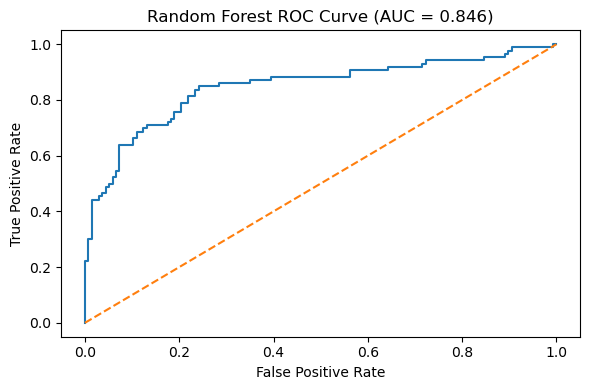

RF Test AUC: 0.8464607027669326


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

best_rf = rf_search.best_estimator_
best_rf.fit(X_train, y_train)   # ensure fitted

# probability for class 1 (Survived=1)
y_prob = best_rf.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Random Forest ROC Curve (AUC = {rf_auc:.3f})")
plt.tight_layout()
plt.show()

print("RF Test AUC:", rf_auc)


### Top-k features sweep

We then performed a simple top-k sweep: starting from the most important features, we retrained the RF using only the top-k transformed features and evaluated performance using 5-fold stratified CV on the training set. Accuracy increased as k grew, and peaked at k=24 with mean CV accuracy 0.8353.

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# transform training set once (after preprocessing)
Xt_train = best_rf.named_steps["preprocessing"].fit_transform(X_train, y_train)

# Create top indices based on sorted importance
top_idx = np.argsort(importances)[::-1]   

# 3) Use the tuned RF params to create a model (same as best model)
best_params = rf_search.best_params_
rf_tuned = RandomForestClassifier(
    n_estimators=best_params["model__n_estimators"],
    max_depth=best_params["model__max_depth"],
    min_samples_split=best_params["model__min_samples_split"],
    min_samples_leaf=best_params["model__min_samples_leaf"],
    max_features=best_params["model__max_features"],
    class_weight=best_params["model__class_weight"],
    random_state=42,
    n_jobs=-1
)

# 4) Try different k 
k_list = [5, 8, 10, 12, 16, 20, 24, 28, 32]

rows = []
for k in k_list:
    cols = top_idx[:k]
    Xt_k = Xt_train[:, cols]

    scores = cross_val_score(rf_tuned, Xt_k, y_train, cv=cv, scoring="accuracy")
    rows.append({
        "k": k,
        "cv_mean_acc": scores.mean(),
        "cv_std": scores.std()
    })

results_df = pd.DataFrame(rows)
display(results_df)


,k,cv_mean_acc,cv_std
0,5,0.806913,0.018246
1,8,0.818887,0.017747
2,10,0.827820,0.017352
3,12,0.827797,0.019974
4,16,0.829312,0.017010
5,20,0.829335,0.016091
6,24,0.835327,0.016453
7,28,0.833812,0.016234
8,32,0.832297,0.017822


### pick smallest K within tolerance

With a tolerance of 0.005 (0.5%) from the best CV score, we selected k=24 as the smallest feature set meeting this threshold. Since the transformed feature space has 32 features, this reduces the feature set by 25% while keeping CV performance nearly unchanged.

In [19]:

tolerance = 0.005  # allow up to 0.5% drop from the best CV mean accuracy

best_mean = results_df["cv_mean_acc"].max()
threshold = best_mean - tolerance

# choose the smallest k whose mean accuracy >= threshold
best_k = int(
    results_df[results_df["cv_mean_acc"] >= threshold]
    .sort_values("k")
    .iloc[0]["k"]
)

print("Best CV mean accuracy:", best_mean)
print("Threshold (best - tolerance):", threshold)
print("Chosen smallest k:", best_k)


Best CV mean accuracy: 0.8353271237795983
Threshold (best - tolerance): 0.8303271237795983
Chosen smallest k: 24


In [20]:
from sklearn.metrics import roc_auc_score, roc_curve

#transform train/test once using the SAME preprocessing fitted on train ----
preproc = best_rf.named_steps["preprocessing"]   
Xt_train = preproc.transform(X_train)
Xt_test  = preproc.transform(X_test)

# select top-k columns ----
k = best_k  # = 24
cols = top_idx[:k]
Xt_train_k = Xt_train[:, cols]
Xt_test_k  = Xt_test[:, cols]

#fit top-k RF and compute AUC on test ----
rf_tuned.fit(Xt_train_k, y_train)
y_prob_topk = rf_tuned.predict_proba(Xt_test_k)[:, 1]

auc_topk = roc_auc_score(y_test, y_prob_topk)
auc_topk


0.8456119504328637

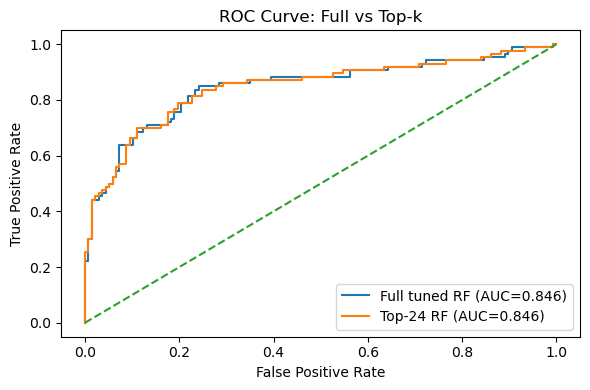

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# full model
y_prob_full = best_rf.predict_proba(X_test)[:, 1]
fpr_full, tpr_full, _ = roc_curve(y_test, y_prob_full)
auc_full = roc_auc_score(y_test, y_prob_full)

# top-k model
y_prob_topk = rf_tuned.predict_proba(Xt_test_k)[:, 1]
fpr_k, tpr_k, _ = roc_curve(y_test, y_prob_topk)
auc_topk = roc_auc_score(y_test, y_prob_topk)

plt.figure(figsize=(6,4))
plt.plot(fpr_full, tpr_full, label=f"Full tuned RF (AUC={auc_full:.3f})")
plt.plot(fpr_k, tpr_k, label=f"Top-{k} RF (AUC={auc_topk:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Full vs Top-k")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# List out the selected top-k features (k=24)
selected_feature_names = feature_names[top_idx[:best_k]]

print("Selected top-k features (k=24):")
for f in selected_feature_names:
    print(f)

Selected top-k features (k=24):
cat__title_group_Mr
cat__Sex_male
cat__Sex_female
num__fare_per_person
num__cabin_score
num__Fare
num__Age
num__age_fare_ratio
cat__Pclass_3
num__ticket_group_size
num__family_size
cat__cabin_deck_Unknown
num__SibSp
cat__title_group_Miss
cat__title_group_Mrs
cat__Embarked_S
cat__title_group_Other
cat__cabin_deck_D
cat__Pclass_1
cat__title_group_Master
cat__Embarked_C
cat__cabin_deck_E
cat__Pclass_2
num__Parch


### Final evaluation on the test set

After selecting k=24, we refit preprocessing on the full training set, trained the tuned RF on the top-k features, and evaluated once on the held-out test set. The top-k model achieved test accuracy = 0.8117 with confusion matrix \[122,15,27,59]. This indicates the model makes relatively few false positives (15), while some survivors are predicted as non-survivors (27), suggesting recall for the Survived class is lower than precision.

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Transform train/test using preprocessing (fit on train only)
Xt_train = best_rf.named_steps["preprocessing"].fit_transform(X_train, y_train)
Xt_test  = best_rf.named_steps["preprocessing"].transform(X_test)

# Select top-k columns
cols = top_idx[:best_k]
Xt_train_k = Xt_train[:, cols]
Xt_test_k  = Xt_test[:, cols]

# Fit tuned RF on reduced features
rf_tuned.fit(Xt_train_k, y_train)

# Predict on test
y_pred = rf_tuned.predict(Xt_test_k)

print("Test accuracy (top-k):", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Test accuracy (top-k): 0.8116591928251121
Confusion matrix:
 [[122  15]
 [ 27  59]]


## Random Forest (RF) Summary

### Setup
- Train/test split: 75/25 with `stratify=y`, `random_state=42`
- 5-fold Stratified CV (`shuffle=True`, `random_state=42`)
- Preprocessing: median imputation for numeric, most-frequent imputation + one-hot encoding for categorical features

### Step 2 — RF Baseline (CV on training set)
- CV accuracy scores: [0.7985, 0.8433, 0.8433, 0.8271, 0.7970]
- Mean CV accuracy = **0.8218**, Std = **0.0205**

### Step 3 — RF Hyperparameter Tuning (RandomizedSearchCV)
- 30 random candidates × 5 folds = 150 total fits (train-only CV)
- Best mean CV accuracy = **0.8353**
- Best params:
  - `n_estimators=1200`, `max_depth=30`, `min_samples_split=10`, `min_samples_leaf=2`,
  - `max_features=0.5`, `class_weight=None`

### Step 4 — Small yet performant (Top-k feature reduction)
- Feature count:
  - p (raw) = **15**
  - p (after preprocessing) = **32**
- Used RF built-in `feature_importances_` to rank transformed features (e.g., title group, sex, fare, cabin, age, Pclass)
- Top-k sweep (5-fold CV):
  - Best mean CV accuracy = **0.8353**
  - Tolerance = **0.005** (0.5 percentage points)
  - Threshold = **0.8303**
  - Chosen smallest k within tolerance = **24**
- This reduces transformed features from **32 → 24** (**25% reduction**) while keeping CV performance near the best.

### Final Test Evaluation (Top-k model)
- Test accuracy (k=24) = **0.8117**
- Confusion matrix:
  - [[122, 15],
     [27, 59]]
  - The model makes relatively few false positives (15), while some survivors are predicted as non-survivors (27).


## Method

We trained a Random Forest classifier to predict passenger survival. The dataset was split into training and test sets using a 75/25 split with stratification on the target label (random_state=42). All model selection steps were performed on the training set only using 5-fold Stratified cross-validation (shuffle=True, seed=42). Preprocessing was implemented using a pipeline: numeric features were median-imputed, categorical features were imputed with the most frequent category and one-hot encoded. We first established a baseline RF using CV, then tuned hyperparameters with RandomizedSearchCV (30 random candidates evaluated by 5-fold CV, totalling 150 fits). Finally, to support the project goal of building a “small yet performant” model, we ranked transformed features using the tuned RF’s built-in impurity-based feature importance (feature_importances_) and performed a top-k feature sweep. We selected the smallest k whose mean CV accuracy was within a tolerance of 0.005 (0.5 percentage points) of the best observed CV score.

## Result

The baseline Random Forest achieved mean CV accuracy 0.8218 (std 0.0205) on the training set. After tuning, the best model achieved mean CV accuracy 0.8353 with parameters: n_estimators=1200, max_depth=30, min_samples_split=10, min_samples_leaf=2, max_features=0.5, class_weight=None. After preprocessing, the model operated on 32 transformed features (from 15 raw predictors). Using the importance ranking and top-k sweep, we found that k=24 features achieved the best observed mean CV accuracy (0.8353) and was also the smallest k within the tolerance threshold (0.8303), reducing the transformed feature set from 32 to 24 (a 25% reduction) while maintaining near-peak CV performance. The final top-k model achieved test accuracy = 0.8117 with confusion matrix \[122,15,27,59], indicating relatively few false positives but a moderate number of false negatives for the Survived class.